## Rubric

Instructions: DELETE this cell before you submit via a `git push` to your repo before deadline. This cell is for your reference only and is not needed in your report. 

 Scoring: Out of 10 points

- Each Developing  => -2 pts
- Each Unsatisfactory/Missing => -4 pts
  - until the score is 0

If students address the detailed feedback in a future checkpoint they will earn these points back






|                                  | **Unsatisfactory**                                                                                                                                                                                                                                                                                                                        | **Developing**                                                                                                                                                                                                       | **Proficient**                                                                                                                                                                                            | **Excellent**                                                                                                                                                                            |
|----------------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **EDA relevance**                | EDA is mostly neither relevant to the question nor helpful in figuring out how to address the question. Or the EDA does address the question, but many obviously relevant variables / analyses / figures were not included. | EDA is partly irrelevant/unhelpful. EDA missed one or two obvioulsy relevant analysis (distributions of single variables or relationships between variables) | EDA includes the obviously relevant / helpful variables in addressing the question.                                                              | Thorough EDA fully explored the dataset                                                                                                                 |
| **EDA analysis and description** | Many of the analyses are poor choices (e.g., using means instead of medians for obviously skewed data), or are poorly described in the text, or do not aid understanding the data                                                                                                                                                     | Some of the analyses are poor choices, or are poorly described in the text, or do not aid understanding the data                                                                                                 | All analyses are correct choices. Only one or two have minor issues in the text descriptions supporting them. Mostly they fit well with other elements of the EDA and support understanding the data  | All analyses are correct choices with clear text descriptions supporting them. The figures fit well with the other elements of the EDA, producing a clear understanding of the data. |
| **EDA figures**                  | Many of the figures are poor plot choices (e.g., using a bar plot to represent a time series where it would be better to use a line plot) or have poor aesthetics (including colormap, data point shape/color, axis labels, titles, annotations, text legibility) or do not aid understanding the data                                | Some of the figures are poor plot choices or have poor aesthetics. Some figures do not aid understanding the data                                                                                                | All figures are correct plot choices. Only one or two have minor questionable aesthetic choices. The figures mostly fit well with the other elements of the EDA and support understanding the data    | All figures are correct plot choices with beautiful aesthetics. The figures fit well with the other elements of the EDA, producing a clear understanding of the data.                |





# COGS 108 - EDA Checkpoint

## Authors

Instructions: REPLACE the contents of this cell with your team list and their contributions. Note that this will change over the course of the checkpoints

This is a modified [CRediT taxonomy of contributions](https://credit.niso.org). For each group member please list how they contributed to this project using these terms:
> Analysis, Background research, Conceptualization, Data curation, Experimental investigation, Methodology, Project administration, Software, Visualization, Writing – original draft, Writing – review & editing

Example team list and credits:
- Alice Anderson: Conceptualization, Data curation, Methodology, Writing - original draft
- Bob Barker:  Analysis, Software, Visualization
- Charlie Chang: Project administration, Software, Writing - review & editing
- Dani Delgado: Analysis, Background research, Visualization, Writing - original draft

# Research Question

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback



## Background and Prior Work

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

# Hypothesis


Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Data

### Data overview

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your data checkpoint feedback


In [1]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

In [2]:
# Setup code -- Run only once after cloning!!! 
#
# this code downloads the data from its source to the `data/00-raw/` directory
# if the data hasn't updated you don't need to do this again!

# if you don't already have these packages (you should!) uncomment this line
# %pip install requests tqdm

import sys
sys.path.append('./modules') # this tells python where to look for modules to import

import get_data # this is where we get the function we need to download data

# replace the urls and filenames in this list with your actual datafiles
# yes you can use Google drive share links or whatever
# format is a list of dictionaries; 
# each dict has keys of 
#   'url' where the resource is located
#   'filename' for the local filename where it will be stored 
#datafiles = [
#    { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/airline-safety/airline-safety.csv', 'filename':'airline-safety.csv'},
#    { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/bad-drivers/bad-drivers.csv', 'filename':'bad-drivers.csv'}
#]

#get_data.get_raw(datafiles,destination_directory='data/00-raw/')

In [3]:
# Import basic packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels
import statsmodels.api as sm
import statsmodels.formula.api as smf
import scipy.stats as stats
from scipy.stats import ttest_ind, chisquare, normaltest, kstest, norm
import os
import glob

### Dataset #1 

Instructions: REPLACE the contents of this cell and the one below with your work, including any updates to recover points lost in your data checkpoint feedback

In [4]:
# Load in weekly anxiety/depression survey data.
d19 = pd.read_csv('data/00-raw/GLOBEMDataset/INS-W_2/SurveyData/dep_weekly.csv')
d20 = pd.read_csv('data/00-raw/GLOBEMDataset/INS-W_3/SurveyData/dep_weekly.csv')
d21 = pd.read_csv('data/00-raw/GLOBEMDataset/INS-W_4/SurveyData/dep_weekly.csv')

# Create a list of columns we want to drop in our dataframe.
d_drop_columns = ['Unnamed: 0', 'dep', 'BDI2', 'dep_weekly_subscale', 'anx_weekly_subscale', 'dep_weeklysubscale_endterm_merged']

# Drop all columns to the right of PHQ-4.
d19_1 = d19.drop(columns=d_drop_columns)
d20_1 = d20.drop(columns=d_drop_columns)
d21_1 = d21.drop(columns=d_drop_columns)

# Drop rows with missing values.
d19_clean = d19_1.dropna(axis=0, how='any', inplace=False)
d20_clean = d20_1.dropna(axis=0, how='any', inplace=False)
d21_clean = d21_1.dropna(axis=0, how='any', inplace=False)

# Convert 'date' column type from string to datetime.
d19_clean['date'] = pd.to_datetime(d19_clean['date'])
d20_clean['date'] = pd.to_datetime(d20_clean['date'])
d21_clean['date'] = pd.to_datetime(d21_clean['date'])

C:\Users\Liza\AppData\Local\Temp\ipykernel_25768\2136067717.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d19_clean['date'] = pd.to_datetime(d19_clean['date'])
C:\Users\Liza\AppData\Local\Temp\ipykernel_25768\2136067717.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d20_clean['date'] = pd.to_datetime(d20_clean['date'])
C:\Users\Liza\AppData\Local\Temp\ipykernel_25768\2136067717.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_

In [5]:
# Load in sleep data.
s19 = pd.read_csv('data/00-raw/GLOBEMDataset/INS-W_2/FeatureData/sleep.csv')
s20 = pd.read_csv('data/00-raw/GLOBEMDataset/INS-W_3/FeatureData/sleep.csv')
s21 = pd.read_csv('data/00-raw/GLOBEMDataset/INS-W_4/FeatureData/sleep.csv')

# Create a list of columns we want to keep in our dataframe.
s_keep_columns = ['pid', 'date', 'f_slp:fitbit_sleep_summary_rapids_sumdurationasleepmain:7dhist']

# Create dfs using only the desired columns.
s19_1 = s19[s_keep_columns]
s20_1 = s20[s_keep_columns]
s21_1 = s21[s_keep_columns]

# Rename the sleep duration column.
s19_1.rename(columns={'f_slp:fitbit_sleep_summary_rapids_sumdurationasleepmain:7dhist': 'mainsleep_dur:7d'}, inplace=True)
s20_1.rename(columns={'f_slp:fitbit_sleep_summary_rapids_sumdurationasleepmain:7dhist': 'mainsleep_dur:7d'}, inplace=True)
s21_1.rename(columns={'f_slp:fitbit_sleep_summary_rapids_sumdurationasleepmain:7dhist': 'mainsleep_dur:7d'}, inplace=True)

# Drop rows with missing values.
s19_clean = s19_1.dropna(axis=0, how='any', inplace=False)
s20_clean = s20_1.dropna(axis=0, how='any', inplace=False)
s21_clean = s21_1.dropna(axis=0, how='any', inplace=False)

# Convert 'date' column type from string to datetime.
s19_clean['date'] = pd.to_datetime(s19_clean['date'])
s20_clean['date'] = pd.to_datetime(s20_clean['date'])
s21_clean['date'] = pd.to_datetime(s21_clean['date'])

C:\Users\Liza\AppData\Local\Temp\ipykernel_25768\3782717788.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  s19_1.rename(columns={'f_slp:fitbit_sleep_summary_rapids_sumdurationasleepmain:7dhist': 'mainsleep_dur:7d'}, inplace=True)
C:\Users\Liza\AppData\Local\Temp\ipykernel_25768\3782717788.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  s20_1.rename(columns={'f_slp:fitbit_sleep_summary_rapids_sumdurationasleepmain:7dhist': 'mainsleep_dur:7d'}, inplace=True)
C:\Users\Liza\AppData\Local\Temp\ipykernel_25768\3782717788.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFr

### Dataset #2
 as above, add any more copies of this that you need to given how many datasets you have

In [6]:
w19 = pd.read_csv('data/00-raw/weather-2019.csv') 
print("\nRaw dataset:\n",w19.head())
#change column name and clear first two row
w19_tidy = w19.rename(columns={'latitude': 'date', 'longitude': 'avg_temperature_F'}) #change column name
w19_tidy = w19_tidy.iloc[2:] 
print("\nTidied dataset:\n",w19_tidy.head())

w19_tidy.to_csv('data/01-interim/weather-2019_tidied.csv',index=False)
print(f"\nTidying complete. Processed file saved to: 'data/01-interim/weather-2019_tidied.csv'")

#THE SIZE OF THE DATASET
print(f"\nDataset Shape: {w19_tidy.shape}")

#MISSING DATA
missing_counts = w19_tidy.isnull().sum()
print("\nMissing values per column:\n", missing_counts)

#OUTLIERS AND SUSPICIOUS ENTRIES
w19_tidy['avg_temperature_F'] = pd.to_numeric(w19_tidy['avg_temperature_F'], errors='coerce')
q1 = w19_tidy['avg_temperature_F'].quantile(0.25)
q3 = w19_tidy['avg_temperature_F'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = w19_tidy[(w19_tidy['avg_temperature_F'] < lower_bound) | (w19_tidy['avg_temperature_F'] > upper_bound)]
w19_tidy['is_outlier'] = (w19_tidy['avg_temperature_F'] < lower_bound) | (w19_tidy['avg_temperature_F'] > upper_bound)

print(f"\nNumber of statistical outliers found: {len(outliers)}")
print("\nOutliers flagged\n",w19_tidy.head())

#DATA CLEANING
#w19_clean = w19_tidy[w19_tidy['is_outlier'] == False]
w19_clean = w19_tidy[['date','avg_temperature_F']].copy()

#change hourly data to daily data
w19_clean['date'] = pd.to_datetime(w19_clean['date'])
w19_clean = w19_clean.set_index('date')
w19_clean = w19_clean.resample('D').mean().reset_index()
w19_clean['avg_temperature_F'] = w19_clean['avg_temperature_F'].round(1)
w19_clean = w19_clean.infer_objects(copy=False)

print("\nCleaned dataset:\n",w19_clean.head())
w19_clean.to_csv('data/02-processed/weather-2019_cleaned.csv',index=False)
print(f"\nWrangling complete. Processed file saved to: 'data/02-processed/weather-2019_cleaned.csv'")


Raw dataset:
            latitude            longitude  elevation  utc_offset_seconds  \
0         47.627415           -122.32291       59.0            -28800.0   
1              time  temperature_2m (°F)        NaN                 NaN   
2  2019-03-21T00:00                 51.3        NaN                 NaN   
3  2019-03-21T01:00                 50.6        NaN                 NaN   
4  2019-03-21T02:00                 49.7        NaN                 NaN   

              timezone timezone_abbreviation  
0  America/Los_Angeles                 GMT-8  
1                  NaN                   NaN  
2                  NaN                   NaN  
3                  NaN                   NaN  
4                  NaN                   NaN  

Tidied dataset:
                date avg_temperature_F  elevation  utc_offset_seconds timezone  \
2  2019-03-21T00:00              51.3        NaN                 NaN      NaN   
3  2019-03-21T01:00              50.6        NaN                 NaN    

In [7]:
w20 = pd.read_csv('data/00-raw/weather-2020.csv') 
print("\nRaw dataset:\n",w20.head())
#TIDY DATA
w20_tidy = w20.rename(columns={'latitude': 'date', 'longitude': 'avg_temperature_F'}) #change column name
w20_tidy = w20_tidy.iloc[2:] 
print("\nTidied dataset:\n",w20_tidy.head())

w20_tidy.to_csv('data/01-interim/weather-2020_tidied.csv',index=False)
print(f"\nTidying complete. Processed file saved to: 'data/01-interim/weather-2020_tidied.csv'")

#THE SIZE OF THE DATASET
print(f"\nDataset Shape: {w20_tidy.shape}")

#MISSING DATA
missing_counts = w20_tidy.isnull().sum()
print("\nMissing values per column:\n", missing_counts)

#OUTLIERS AND SUSPICIOUS ENTRIES
w20_tidy['avg_temperature_F'] = pd.to_numeric(w20_tidy['avg_temperature_F'], errors='coerce')
q1 = w20_tidy['avg_temperature_F'].quantile(0.25)
q3 = w20_tidy['avg_temperature_F'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = w20_tidy[(w20_tidy['avg_temperature_F'] < lower_bound) | (w20_tidy['avg_temperature_F'] > upper_bound)]
w20_tidy['is_outlier'] = (w20_tidy['avg_temperature_F'] < lower_bound) | (w20_tidy['avg_temperature_F'] > upper_bound)

print(f"\nNumber of statistical outliers found: {len(outliers)}")
print("\nOutliers flagged\n",w20_tidy.head())

#DATA CLEANING
#w20_clean = w20_tidy[w20_tidy['is_outlier'] == False]
w20_clean = w20_tidy[['date','avg_temperature_F']].copy()
#change hourly data to daily data
w20_clean['date'] = pd.to_datetime(w20_clean['date'])
w20_clean = w20_clean.set_index('date')
w20_clean = w20_clean.resample('D').mean().reset_index()
w20_clean['avg_temperature_F'] = w20_clean['avg_temperature_F'].round(1)
w20_clean = w20_clean.infer_objects(copy=False)

print("\nCleaned dataset:\n",w20_clean.head())
w20_clean.to_csv('data/02-processed/weather-2020_cleaned.csv',index=False)
print(f"\nWrangling complete. Processed file saved to: 'data/02-processed/weather-2020_cleaned.csv'")


Raw dataset:
            latitude            longitude  elevation  utc_offset_seconds  \
0         47.627415           -122.32291       59.0            -28800.0   
1              time  temperature_2m (°F)        NaN                 NaN   
2  2020-03-16T00:00                 39.6        NaN                 NaN   
3  2020-03-16T01:00                 39.1        NaN                 NaN   
4  2020-03-16T02:00                 39.2        NaN                 NaN   

              timezone timezone_abbreviation  
0  America/Los_Angeles                 GMT-8  
1                  NaN                   NaN  
2                  NaN                   NaN  
3                  NaN                   NaN  
4                  NaN                   NaN  

Tidied dataset:
                date avg_temperature_F  elevation  utc_offset_seconds timezone  \
2  2020-03-16T00:00              39.6        NaN                 NaN      NaN   
3  2020-03-16T01:00              39.1        NaN                 NaN    

In [8]:
w21 = pd.read_csv('data/00-raw/weather-2021.csv') 
print("\nRaw dataset:\n",w21.head())
#change column name and clear first two row
w21_tidy = w21.rename(columns={'latitude': 'date', 'longitude': 'avg_temperature_F'}) #change column name
w21_tidy = w21_tidy.iloc[2:] 
print("\nTidied dataset:\n",w21_tidy.head())

w21_tidy.to_csv('data/01-interim/weather-2021_tidied.csv',index=False)
print(f"\nTidying complete. Processed file saved to: 'data/01-interim/weather-2021_tidied.csv'")

#THE SIZE OF THE DATASET
print(f"\nDataset Shape: {w21_tidy.shape}")

#MISSING DATA
missing_counts = w21_tidy.isnull().sum()
print("\nMissing values per column:\n", missing_counts)

#OUTLIERS AND SUSPICIOUS ENTRIES
w21_tidy['avg_temperature_F'] = pd.to_numeric(w21_tidy['avg_temperature_F'], errors='coerce')
q1 = w21_tidy['avg_temperature_F'].quantile(0.25)
q3 = w21_tidy['avg_temperature_F'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = w21_tidy[(w21_tidy['avg_temperature_F'] < lower_bound) | (w21_tidy['avg_temperature_F'] > upper_bound)]
w21_tidy['is_outlier'] = (w21_tidy['avg_temperature_F'] < lower_bound) | (w21_tidy['avg_temperature_F'] > upper_bound)

print(f"\nNumber of statistical outliers found: {len(outliers)}")
print("\nOutliers flagged\n",w21_tidy.head())

#DATA CLEANING
#w21_clean = w21_tidy[w21_tidy['is_outlier'] == False]
w21_clean = w21_tidy[['date','avg_temperature_F']].copy()

#change hourly data to daily data
w21_clean['date'] = pd.to_datetime(w21_clean['date'])
w21_clean = w21_clean.set_index('date')
w21_clean = w21_clean.resample('D').mean().reset_index()
w21_clean['avg_temperature_F'] = w21_clean['avg_temperature_F'].round(1)
w21_clean = w21_clean.infer_objects(copy=False)

print("\nCleaned dataset:\n",w21_clean.head())
w21_clean.to_csv('data/02-processed/weather-2021_cleaned.csv',index=False)
print(f"\nWrangling complete. Processed file saved to: 'data/02-processed/weather-2021_cleaned.csv'")


Raw dataset:
            latitude            longitude  elevation  utc_offset_seconds  \
0         47.627415           -122.32291       59.0            -28800.0   
1              time  temperature_2m (°F)        NaN                 NaN   
2  2021-03-29T00:00                 38.5        NaN                 NaN   
3  2021-03-29T01:00                 37.7        NaN                 NaN   
4  2021-03-29T02:00                 37.1        NaN                 NaN   

              timezone timezone_abbreviation  
0  America/Los_Angeles                 GMT-8  
1                  NaN                   NaN  
2                  NaN                   NaN  
3                  NaN                   NaN  
4                  NaN                   NaN  

Tidied dataset:
                date avg_temperature_F  elevation  utc_offset_seconds timezone  \
2  2021-03-29T00:00              38.5        NaN                 NaN      NaN   
3  2021-03-29T01:00              37.7        NaN                 NaN    

#### Combine the weather datasets with anxiety/depression and sleep datasets.

In [9]:
# Merge the dep_weekly and weather dataframes, using 'date' as the common column.
dw19 = pd.merge(d19_clean, w19_clean, on='date', how='left')
dw20 = pd.merge(d19_clean, w20_clean, on='date', how='left')
dw21 = pd.merge(d19_clean, w21_clean, on='date', how='left')

# Merge the sleep and weather dataframes, using 'date' as the common column.
sw19 = pd.merge(s19_clean, w19_clean, on='date', how='left')
sw20 = pd.merge(s20_clean, w20_clean, on='date', how='left')
sw21 = pd.merge(s21_clean, w21_clean, on='date', how='left')

# Merging dw19 and sw19 dataframes into one dataset, using 'date' as the common column. 
final19 = (
    d19_clean
        .merge(w19_clean, on='date', how='left')
        .merge(s19_clean, on=['pid', 'date'], how='left')
)

# Merging dw20 and sw20 dataframes into one dataset, using 'date' as the common column.
final20 = (
    d20_clean
        .merge(w20_clean, on='date', how='left')
        .merge(s20_clean, on=['pid', 'date'], how='left')
)

# Merging dw21 and sw21 dataframes into one dataset, using 'date' as the common column.
final21 = (
    d21_clean
        .merge(w21_clean, on='date', how='left')
        .merge(s21_clean, on=['pid', 'date'], how='left')
)

# Adding year column to final19, final20, and final21 dataframes.
final19['year'] = 2019
final20['year'] = 2020
final21['year'] = 2021

# Merging final19, final20, final21 into one dataframe.
final_all = pd.concat([final19, final20, final21], ignore_index=True)

# Merging duplicates for phq4 if there was more than one weekly submission. 
final_all = (
    final_all
    .groupby(['pid','date'], as_index=False)
    .agg({
        'phq4':'mean',
        'avg_temperature_F':'first',
        'mainsleep_dur:7d':'first',
        'year':'first'
    })
)

# Setting 'date' to datetime
final_all['date'] = pd.to_datetime(final_all['date'])

In [10]:
# Sanity checks
print (final_all.shape)
print (final_all.duplicated(subset=['pid', 'date']).sum())
print (final_all.isna().mean().sort_values(ascending=False))
print (final_all[['mainsleep_dur:7d', 'avg_temperature_F', 'phq4']].describe())

(5347, 6)
0
mainsleep_dur:7d     0.199925
avg_temperature_F    0.018515
date                 0.000000
pid                  0.000000
phq4                 0.000000
year                 0.000000
dtype: float64
       mainsleep_dur:7d  avg_temperature_F         phq4
count       4278.000000        5248.000000  5347.000000
mean        2656.273726          53.735061     2.954928
std          699.417938           6.219890     2.837280
min            0.000000          42.800000     0.000000
25%         2352.000000          48.600000     1.000000
50%         2798.000000          52.800000     2.000000
75%         3118.000000          58.100000     4.000000
max         4372.000000          68.300000    12.000000


In [11]:
# Save to data/02-processed/ using Paraquet
out_path = "data/02-processed/final_all_weekly_2019_2021.parquet"
final_all.to_parquet(out_path, index=False)
print("Saved:", out_path)
print("Bytes:", os.path.getsize(out_path))

Saved: data/02-processed/final_all_weekly_2019_2021.parquet
Bytes: 29810


## Results

### Exploratory Data Analysis

Instructions: replace the words in this subsection with whatever words you need to setup and preview the EDA you're going to do.   

Please explicitly load the fully wrangled data you will use from `data/02-processed`.  This is a good idea rather than forcing people to re-run the data getting / wrangling cells above.  Sometimes it takes a long time to get / wrangle data compared to reloading the fixed up dataset.

Carry out whatever EDA you need to for your project in the code cells below.  Because every project will be different we can't really give you much of a template at this point. But please make sure you describe the what and why in text here as well as providing interpretation of results and context.

Please note that you should consider the use of python modules in your work.  Any code which gets called repeatedly should be modularized. So if you run the same pre-processing, analysis or visualiazation on different subsets of the data, then you should turn that into a function or class.  Put that function or class in a .py file that lives in `modules/`.  Import the module you made and use it to get your work done.  For reference see `get_raw()` which is inside `modules/get_data.py`. 



#### Section 1 of EDA - please give it a better title than this

Some more words and stuff.  Remember notebooks work best if you interleave the code that generates a result with properly annotate figures and text that puts these results into context.

In [12]:
#Loading in wrangled dataset from data/02-processed
final_all = pd.read_parquet(
    "data/02-processed/final_all_weekly_2019_2021.parquet"
)

final_all.head()

,pid,date,phq4,avg_temperature_F,mainsleep_dur:7d,year
0,INS-W_1000,2021-04-04,2.0,43.9,NaN,2021
1,INS-W_1000,2021-04-11,3.0,42.8,694.0,2021
2,INS-W_1000,2021-04-18,6.0,57.8,NaN,2021
3,INS-W_1000,2021-04-25,1.0,49.6,2116.0,2021
4,INS-W_1000,2021-05-02,5.0,51.6,2345.0,2021


In [13]:
# Checking basic structure of dataset
final_all.shape
final_all.info()
final_all.isna().mean()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5347 entries, 0 to 5346
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   pid                5347 non-null   object        
 1   date               5347 non-null   datetime64[ns]
 2   phq4               5347 non-null   float64       
 3   avg_temperature_F  5248 non-null   float64       
 4   mainsleep_dur:7d   4278 non-null   float64       
 5   year               5347 non-null   int64         
dtypes: datetime64[ns](1), float64(3), int64(1), object(1)
memory usage: 250.8+ KB


pid                  0.000000
date                 0.000000
phq4                 0.000000
avg_temperature_F    0.018515
mainsleep_dur:7d     0.199925
year                 0.000000
dtype: float64

In [14]:
# Removing sleep values less than zero (likely due to tracking errors)
sleep_col = "mainsleep_dur:7d"
final_all.loc[final_all[sleep_col] <= 0, sleep_col] = np.nan

print (final_all[sleep_col].describe())
print (final_all[sleep_col].isna().mean())
print ((final_all[sleep_col] == 0).sum())

# Remove weeks with less than 3 hours per night on average
min_weekly_minutes = 3 * 60 * 7  # 3 hours/night

final_all.loc[
    final_all["mainsleep_dur:7d"] < min_weekly_minutes,
    "mainsleep_dur:7d"
] = np.nan

print (final_all[sleep_col].describe())
print (final_all[sleep_col].isna().mean())
print ((final_all[sleep_col] == 0).sum())

count    4277.000000
mean     2656.894786
std       698.318965
min        58.000000
25%      2352.000000
50%      2798.000000
75%      3118.000000
max      4372.000000
Name: mainsleep_dur:7d, dtype: float64
0.20011221245558258
0
count    4055.000000
mean     2762.733416
std       541.156410
min      1262.000000
25%      2434.000000
50%      2833.000000
75%      3133.000000
max      4372.000000
Name: mainsleep_dur:7d, dtype: float64
0.24163082102113334
0


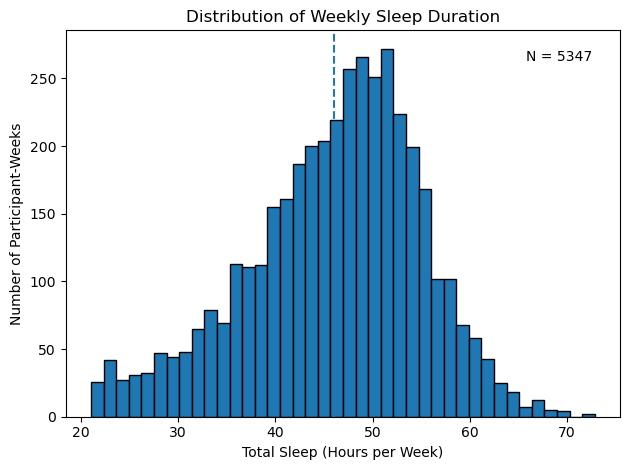

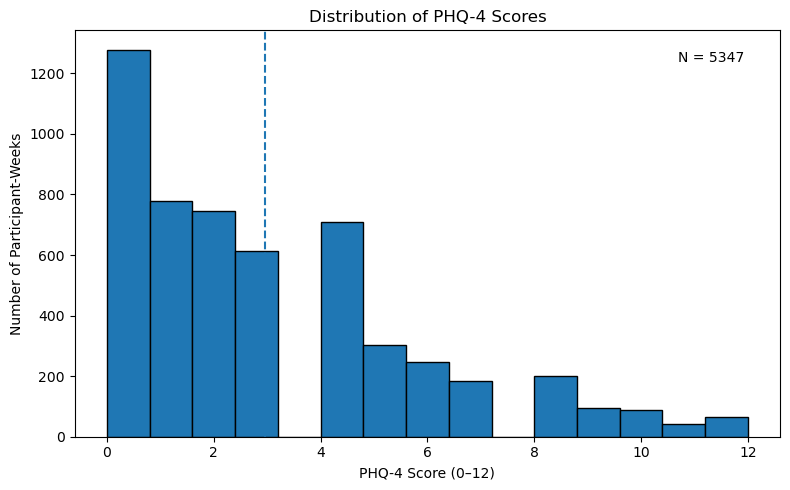

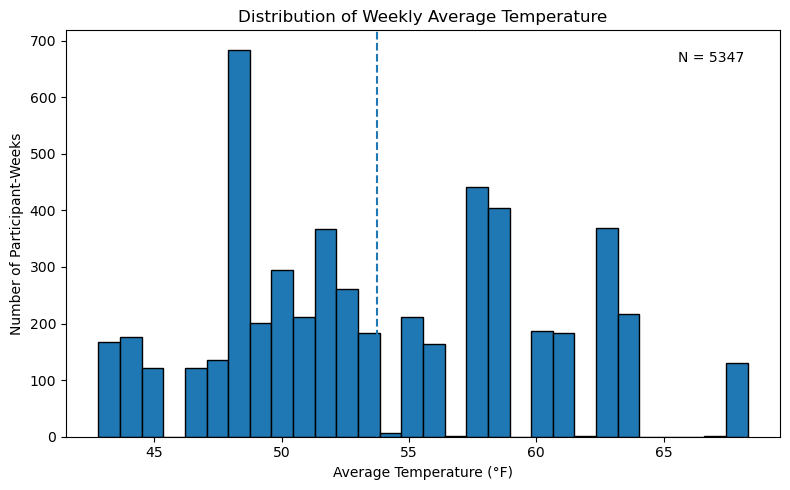

In [15]:
# Convert weekly sleep from minutes to hours
sleep_hours_week = final_all["mainsleep_dur:7d"] / 60

# Common sample size
N = len(final_all)


# Weekly Sleep (converted minutes to hours)
plt.hist(sleep_hours_week, bins=40, edgecolor="black")

plt.title("Distribution of Weekly Sleep Duration")
plt.xlabel("Total Sleep (Hours per Week)")
plt.ylabel("Number of Participant-Weeks")

plt.axvline(sleep_hours_week.mean(), linestyle="dashed")

plt.text(
    0.95, 0.95,
    f"N = {N}",
    transform=plt.gca().transAxes,
    ha="right",
    va="top"
)

plt.tight_layout()
plt.show()


# PHQ-4 Scores
plt.figure(figsize=(8,5))

plt.hist(final_all["phq4"], bins=15, edgecolor="black")

plt.title("Distribution of PHQ-4 Scores")
plt.xlabel("PHQ-4 Score (0–12)")
plt.ylabel("Number of Participant-Weeks")

plt.axvline(final_all["phq4"].mean(), linestyle="dashed")

plt.text(
    0.95, 0.95,
    f"N = {N}",
    transform=plt.gca().transAxes,
    ha="right",
    va="top"
)

plt.tight_layout()
plt.show()


# Average Weekly Temperature

plt.figure(figsize=(8,5))

plt.hist(final_all["avg_temperature_F"], bins=30, edgecolor="black")

plt.title("Distribution of Weekly Average Temperature")
plt.xlabel("Average Temperature (°F)")
plt.ylabel("Number of Participant-Weeks")

plt.axvline(final_all["avg_temperature_F"].mean(), linestyle="dashed")

plt.text(
    0.95, 0.95,
    f"N = {N}",
    transform=plt.gca().transAxes,
    ha="right",
    va="top"
)

plt.tight_layout()
plt.show()


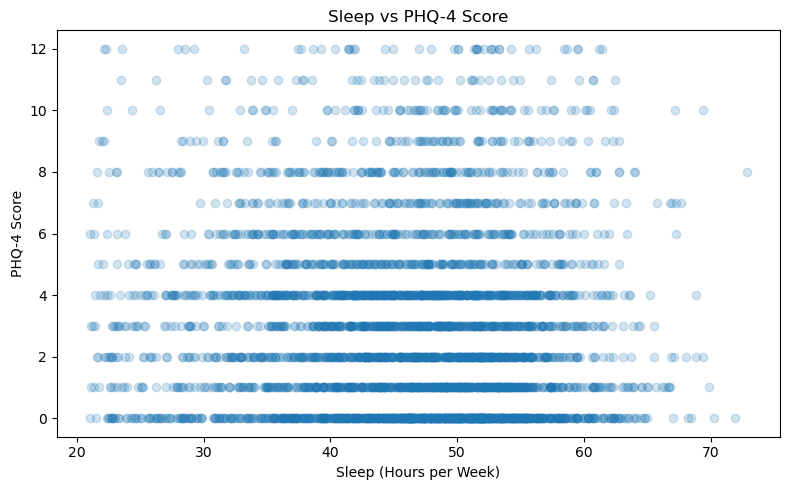

In [16]:
plt.figure(figsize=(8,5))

plt.scatter(
    sleep_hours_week,
    final_all["phq4"],
    alpha=0.2
)

plt.xlabel("Sleep (Hours per Week)")
plt.ylabel("PHQ-4 Score")
plt.title("Sleep vs PHQ-4 Score")

plt.tight_layout()
plt.show()

In [17]:
final_all.assign(
    sleep_hours = final_all["mainsleep_dur:7d"] / 60
)[["sleep_hours", "phq4"]].corr()

,sleep_hours,phq4
sleep_hours,1.000000,-0.068015
phq4,-0.068015,1.000000


#### Section 2 of EDA if you need it  - please give it a better title than this

Some more words and stuff.  Remember notebooks work best if you interleave the code that generates a result with properly annotate figures and text that puts these results into context.

In [18]:
## YOUR CODE HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION

## Ethics

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Team Expectations 

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Project Timeline Proposal

Instructions: Replace this with your timeline.  **PLEASE UPDATE your Timeline!** No battle plan survives contact with the enemy, so make sure we understand how your plans have changed.  Also if you have lost points on the previous checkpoint fix them